In [1]:
import os
import cv2, tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import random
from sklearn.metrics import confusion_matrix
from keras.callbacks import ModelCheckpoint
from keras.models import Sequential
from keras.utils import to_categorical
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
image_dir = 'input/train'
train_folders = os.listdir(image_dir)
Sx = 224
Sy = 224
epocas = 20
train_size = 100
test_size = 20

In [3]:
x_test = []
y_test = []
x_valid = []
y_valid = []
x_train = []
y_train = []

random.seed(42)

for folder in tqdm.tqdm(train_folders):
    folder_path = os.path.join(image_dir, folder)
    images_in_folder = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    random.shuffle(images_in_folder)

    valid_images = images_in_folder[-test_size:]
    test_images = images_in_folder[:test_size]
    train_images = images_in_folder[:train_size]

    for img_path in test_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_test.append(imgRGB)
        y_test.append(folder)

    for img_path in valid_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_valid.append(imgRGB)
        y_valid.append(folder)

    for img_path in train_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_train.append(imgRGB)
        y_train.append(folder)

x_test = np.array(x_test)
x_valid = np.array(x_valid)
x_train = np.array(x_train)

x_test = x_test.astype('float32') / 255.0
x_valid = x_valid.astype('float32') / 255.0
x_train = x_train.astype('float32') / 255.0

x_test = x_test.reshape(-1,Sx,Sy,3)
x_valid = x_valid.reshape(-1,Sx,Sy,3)
x_train = x_train.reshape(-1,Sx,Sy,3)

df = pd.read_csv('input/cards.csv')
category_labels = df.labels.value_counts().index
categories = {}
for index,cat in enumerate(category_labels) :
  categories[cat]=index

y_train = [categories[i] for i in y_train]
y_valid = [categories[i] for i in y_valid]
y_test = [categories[i] for i in y_test]

y_train = to_categorical(y_train)
y_valid = to_categorical(y_valid)
y_test = to_categorical(y_test)

100%|██████████| 53/53 [00:03<00:00, 16.97it/s]


In [4]:
checkpoint = ModelCheckpoint(
    'modelo_final.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [5]:
modelo_final = Sequential([
    Input(shape=(Sx,Sy,3)),
    Conv2D(64 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(256 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(512 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dropout(0.5),
    Dense(256, activation = 'relu'),
    Dropout(0.5),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_final.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_final_metrics = modelo_final.fit(x_train,y_train,validation_data= (x_valid,y_valid), epochs = epocas, callbacks=[checkpoint])

Epoch 1/20
166/166 [==============================] - 51s 236ms/step - loss: 3.9083 - accuracy: 0.0306 - val_loss: 3.2615 - val_accuracy: 0.1491
Epoch 2/20
166/166 [==============================] - 34s 206ms/step - loss: 2.6376 - accuracy: 0.2242 - val_loss: 1.8593 - val_accuracy: 0.3925
Epoch 3/20
166/166 [==============================] - 34s 203ms/step - loss: 1.7978 - accuracy: 0.4053 - val_loss: 1.2461 - val_accuracy: 0.5811
Epoch 4/20
166/166 [==============================] - 34s 205ms/step - loss: 1.4034 - accuracy: 0.5262 - val_loss: 0.9481 - val_accuracy: 0.7009
Epoch 5/20
166/166 [==============================] - 35s 210ms/step - loss: 1.1449 - accuracy: 0.6313 - val_loss: 0.6880 - val_accuracy: 0.8066
Epoch 6/20
166/166 [==============================] - 30s 179ms/step - loss: 0.9635 - accuracy: 0.6962 - val_loss: 0.5398 - val_accuracy: 0.8585
Epoch 7/20
166/166 [==============================] - 30s 180ms/step - loss: 0.8030 - accuracy: 0.7411 - val_loss: 0.4376 - val_ac

In [6]:
modelo_final.evaluate(x_test, y_test)

34/34 [==============================] - 2s 46ms/step - loss: 0.0764 - accuracy: 0.9849


[0.07643073052167892, 0.9849056601524353]

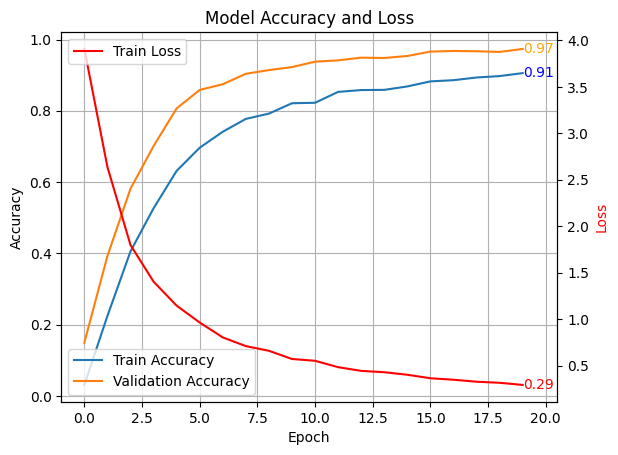

In [26]:
epochs = range(len(modelo_final_metrics.history['accuracy']))
plt.plot(modelo_final_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_final_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower left')
plt.grid(True)
plt.title('Model Accuracy and Loss')
plt.text(epochs[-1], modelo_final_metrics.history['accuracy'][-1], 
         f"{modelo_final_metrics.history['accuracy'][-1]:.2f}", 
         color='blue', va='center')
plt.text(epochs[-1], modelo_final_metrics.history['val_accuracy'][-1], 
         f"{modelo_final_metrics.history['val_accuracy'][-1]:.2f}", 
         color='orange', va='center')
plt.xlim(-1, epochs[-1] + 1.5)
ax2 = plt.gca().twinx()
ax2.plot(modelo_final_metrics.history['loss'], color='red', label='Train Loss')
ax2.set_ylabel('Loss', color='red')
ax2.legend(loc='upper left')
ax2.text(epochs[-1], modelo_final_metrics.history['loss'][-1], 
         f"{modelo_final_metrics.history['loss'][-1]:.2f}", 
         color='red', va='center')

plt.show()

34/34 [==============================] - 2s 63ms/step


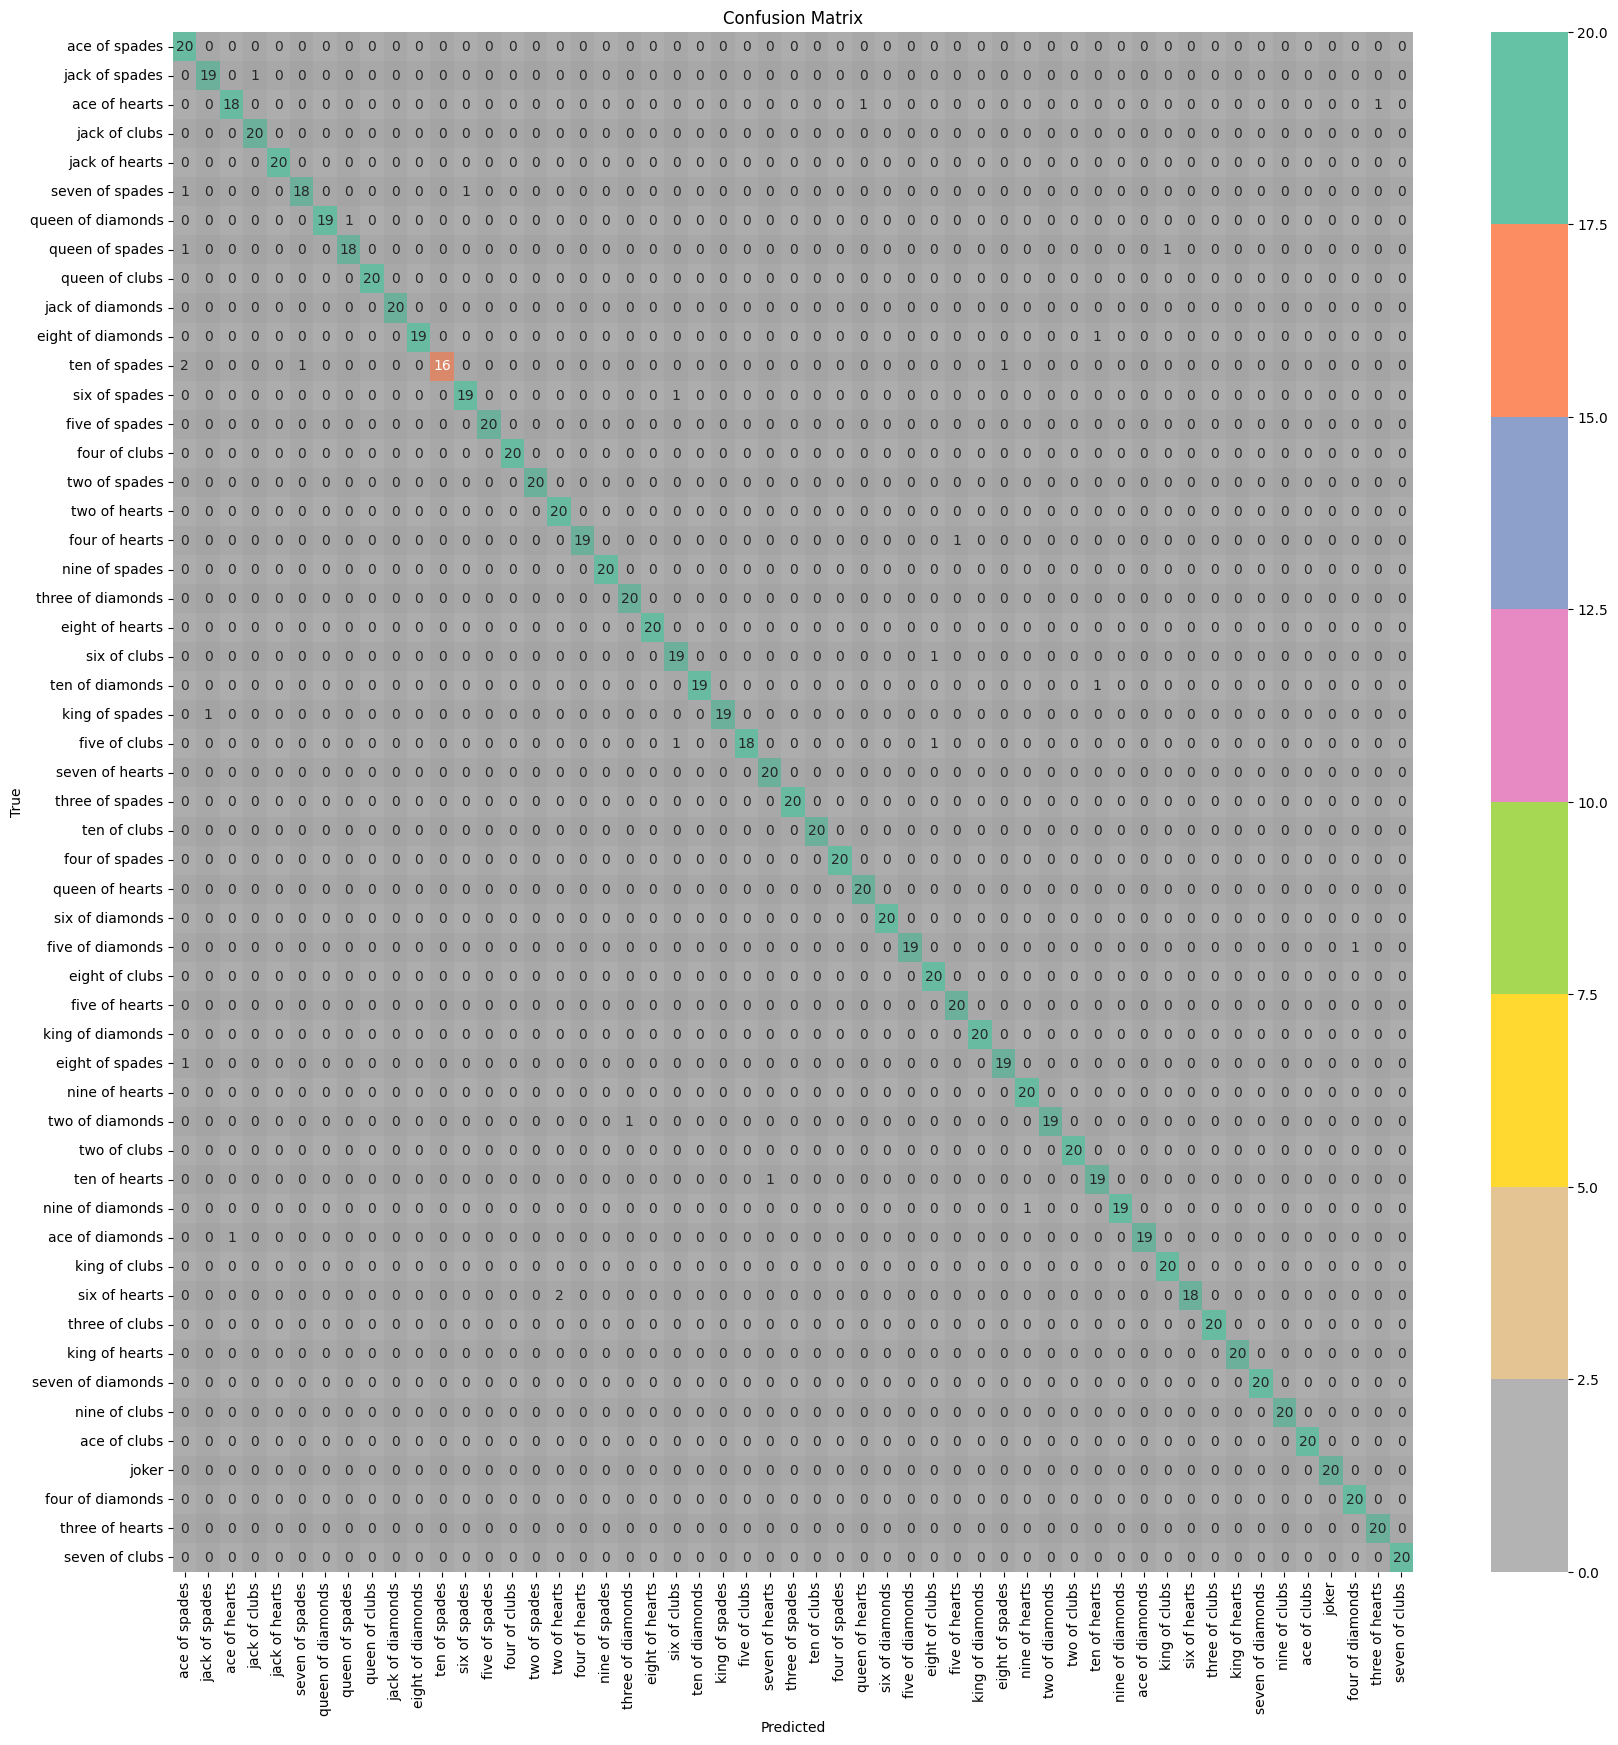

In [8]:
y_pred = modelo_final.predict(x_valid)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_valid, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

id_to_class = {v: k for k, v in categories.items()}
class_names = [id_to_class[i] for i in range(len(id_to_class))]

plt.figure(figsize=(20, 20))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Set2_r',
                 xticklabels=class_names, 
                 yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

num_classes = cm.shape[0]
i = 0
group_count = 0
while i < num_classes:
    a = 0.05 if (group_count % 2 == 0) else 0.15
    ax.add_patch(plt.Rectangle((i, 0), 1, 53, facecolor='gray', alpha=a, edgecolor=None, lw=3, clip_on=False))
    ax.add_patch(plt.Rectangle((0, i), 53, 1, facecolor='gray', alpha=a, edgecolor=None, lw=3, clip_on=False))
    i += 1
    group_count += 1
plt.show()